# EAGLE-Net: Robust Satellite Image Classification

This notebook summarizes the evaluation results for **EAGLE-Net**, a satellite image classification project focused on robustness across image corruptions and deployment tradeoffs.

The goal is to compare three trained models using saved evaluation results and pre-generated plots:

- Baseline CNN
- LightweightCNN
- EAGLE-Net

This is a presentation-style analysis notebook. It does not train models or modify experiment outputs.

## Load Results

Load the saved JSON evaluation files for each model.

In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

results_dir = project_root / "artifacts" / "results"
plots_dir = project_root / "artifacts" / "plots"

with open(results_dir / "baseline_cnn_multi_track.json", "r", encoding="utf-8") as f:
    baseline_cnn_results = json.load(f)

with open(results_dir / "lightweight_cnn_multi_track.json", "r", encoding="utf-8") as f:
    lightweight_cnn_results = json.load(f)

with open(results_dir / "eagle_net_multi_track.json", "r", encoding="utf-8") as f:
    eagle_net_results = json.load(f)

print("Loaded results for Baseline CNN, LightweightCNN, and EAGLE-Net.")

Loaded results for Baseline CNN, LightweightCNN, and EAGLE-Net.


## Accuracy Comparison

The accuracy plot compares how each model performs across the evaluated conditions.

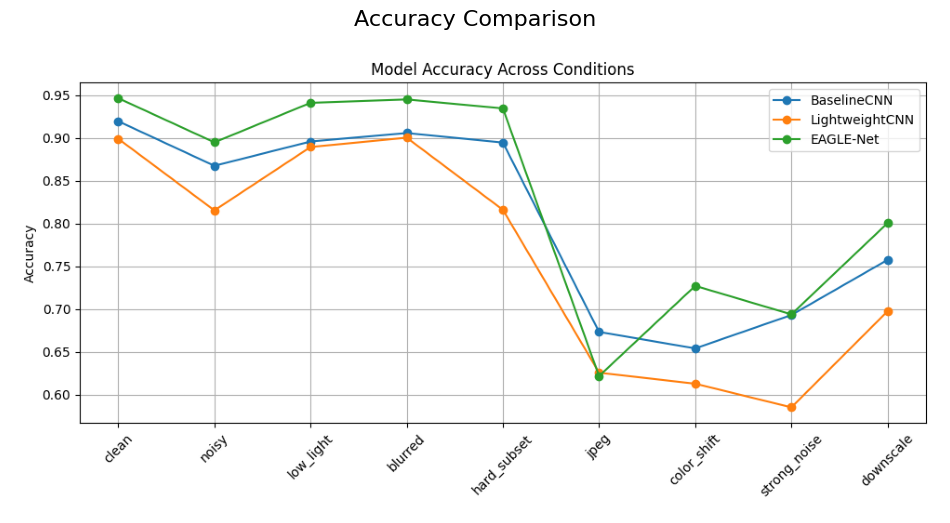

In [10]:
accuracy_plot = Image.open(plots_dir / "accuracy_comparison.png")

plt.figure(figsize=(12, 7))
plt.imshow(accuracy_plot)
plt.axis("off")
plt.title("Accuracy Comparison", fontsize=16, pad=16)
plt.show()

## F1 Score Comparison

The F1 plot highlights model behavior when balancing precision and recall across different corruption settings.

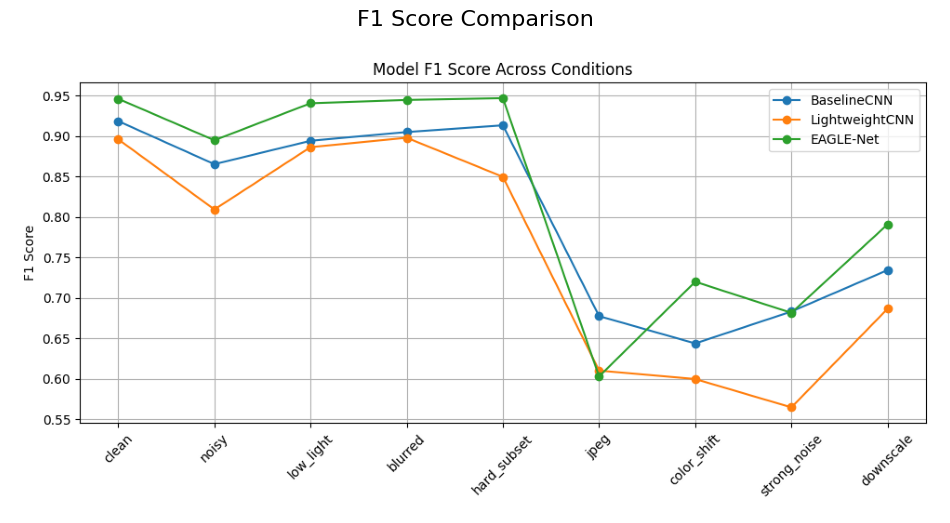

In [11]:
f1_plot = Image.open(plots_dir / "f1_comparison.png")

plt.figure(figsize=(12, 7))
plt.imshow(f1_plot)
plt.axis("off")
plt.title("F1 Score Comparison", fontsize=16, pad=16)
plt.show()

## Latency Tradeoff

The latency tradeoff plot compares predictive performance against runtime efficiency.

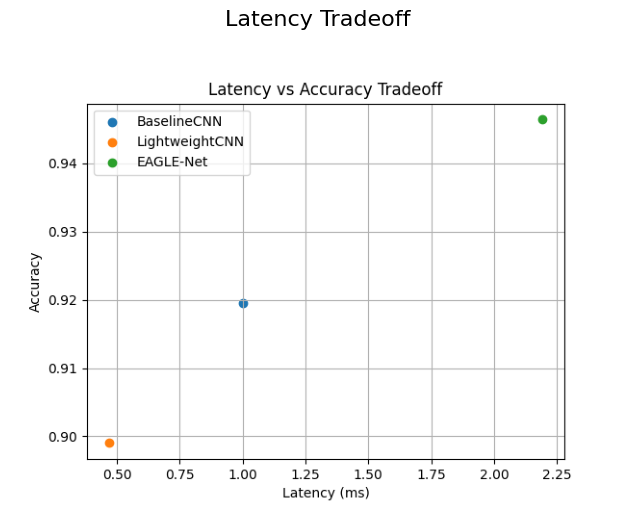

In [12]:
latency_plot = Image.open(plots_dir / "latency_tradeoff.png")

plt.figure(figsize=(10, 6))
plt.imshow(latency_plot)
plt.axis("off")
plt.title("Latency Tradeoff", fontsize=16, pad=16)
plt.show()

## Key Observations

- EAGLE-Net performs best under most conditions.
- Baseline CNN performs better under JPEG compression.
- LightweightCNN is fastest but has lowest accuracy.
- Robustness varies across corruption types.

## Final Insight

Robustness is distribution-dependent: a model that performs well under one type of distortion may not be the strongest under another. These results show that architecture matters, because different model designs respond differently to compression artifacts, noise, blur, and other satellite image distortions.

EAGLE-Net provides the strongest overall robustness profile, while the Baseline CNN and LightweightCNN reveal important tradeoffs between corruption-specific performance and inference speed.